In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['lines.linewidth'] = 2
plt.rcParams["font.size"] = 15

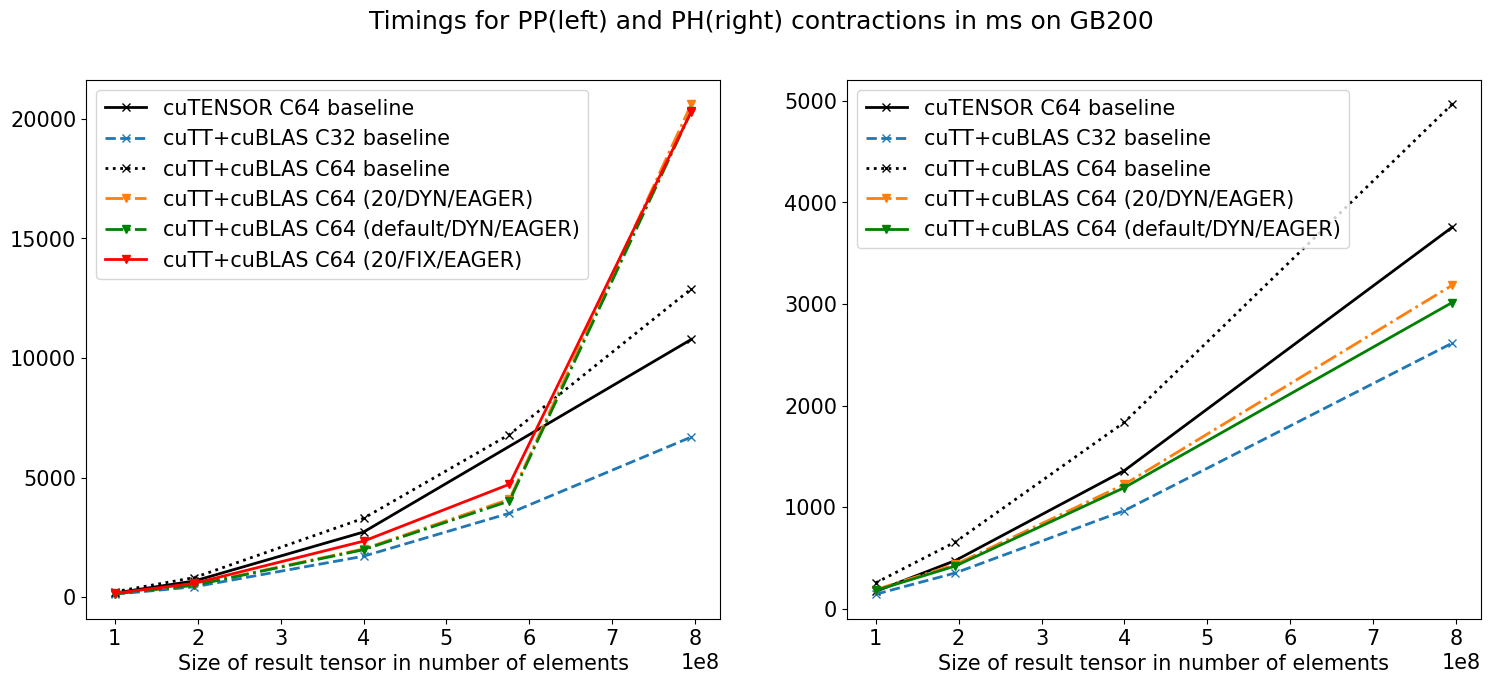

In [4]:
nocc = 100
nvir = [100, 140, 200, 282]

PP_timings_ms = [
    171.06,  # 215.180298
    673.419, # 552.635803
    2720.5,  # 1530.745117
    10775.6  # 
]
PP_timings_ms_CUTT = [
    223.386, 
    816.515, 
    3295.25,
    6799.63,
    12887.6, 
]
PP_timings_ms_CUTT_32 =[
    119.913,
    429.79,
    1708.85,
    3507.87,
    6692.92
]
PP_timings_ms_CUTT_10 = [
    240.372,
    846.82,
    3422.11,
    7049.25,
    20587.4
]
PP_timings_ms_CUTT_20 = [
    141.411,
    507.211,
    2013.7,
    4091.34,
    20613.5
]
PP_timings_ms_CUTT_EMU = [
    137.688,
    493.013,
    1981.17,
    4019.38,
    20313.3
]
PP_timings_ms_CUTT_10_fixed = [
    66.311,
    224.651,
    855.029,
    1696.76,
    20312.4
]
PP_timings_ms_CUTT_20_fixed = [
    158.977,
    574.636,
    2339.84,
    4719.8,
    20306.8
]
PP_timings_ms_CUTT_EMU_PERF = [
    137.889,
    493.277,
    1983.56,
    4028.35,
    20342.4,
]


PH_timings_ms = [
    170.936, 
    474.226, 
    1360.58,
    3755.1
]
PH_timings_ms_CUTT = [
    255.107,
    656.891,
    1835.91,
    4966.04
]
PH_timings_ms_CUTT_32 = [
    142.842,
    352.065,
    966.286,
    2614.21
]
PH_timings_ms_CUTT_10 = [
    281.661,
    703.588,
    1957.51,
    5255.74
]
PH_timings_ms_CUTT_20 = [
    187.914,
    435.761,
    1224.25,
    3183.8
]
PH_timings_ms_CUTT_EMU = [
    180.216,
    420.102,
    1192.86,
    3014.03,
]

#size = ((nocc * np.array(nvir))**2*2*8)/1e9
size = ((nocc * np.array(nvir))**2)
#size_PP = ((nocc * np.array([100, 140, 200, 240, 282]))**2*2*8)/1e9
size_PP = ((nocc * np.array([100, 140, 200, 240, 282]))**2)
fig, axes = plt.subplots(1, 2, sharex=True)
fig.set_size_inches(18, 7)
fig.suptitle("Timings for PP(left) and PH(right) contractions in ms on GB200")
axes[0].plot(size, PP_timings_ms, label="cuTENSOR C64 baseline", marker='x', c='black')
axes[0].plot(size_PP, PP_timings_ms_CUTT_32, label="cuTT+cuBLAS C32 baseline", marker='x', linestyle='--')
axes[0].plot(size_PP, PP_timings_ms_CUTT, label="cuTT+cuBLAS C64 baseline", marker='x', linestyle='dotted', c='black')
#axes[0].plot(size_PP, PP_timings_ms_CUTT_10, label="cuTT+cuBLAS C64 (10 digits)", marker='x')
axes[0].plot(size_PP, PP_timings_ms_CUTT_20, label="cuTT+cuBLAS C64 (20/DYN/EAGER)", marker='v', linestyle='dashdot')
axes[0].plot(size_PP, PP_timings_ms_CUTT_EMU, label="cuTT+cuBLAS C64 (default/DYN/EAGER)", marker='v', linestyle='dashdot', c='green')
#axes[0].plot(size_PP, PP_timings_ms_CUTT_10_fixed, label="cuTT+cuBLAS C64 (10/FIX/EAGER)", marker='v', c='red')
axes[0].plot(size_PP, PP_timings_ms_CUTT_20_fixed, label="cuTT+cuBLAS C64 (20/FIX/EAGER)", marker='v', c='red')
#axes[0].plot(size_PP, PP_timings_ms_CUTT_EMU_PERF, label="cuTT+cuBLAS C64 (default/DYN/PERFO)", marker='^', linestyle='dashdot', c='green')

#axes[0].plot(size, PP_timings_ms_CUTT_10, label="cuTT+cuBLAS (10 digits)", marker='x')
#axes[0].plot(size, PP_timings_ms_CUTT_20, label="cuTT+cuBLAS (20 digits)", marker='x')

axes[1].plot(size, PH_timings_ms, label="cuTENSOR C64 baseline", marker='x', c='black')
axes[1].plot(size, PH_timings_ms_CUTT_32, label="cuTT+cuBLAS C32 baseline", marker='x', linestyle='--')
axes[1].plot(size, PH_timings_ms_CUTT, label="cuTT+cuBLAS C64 baseline", marker='x', linestyle='dotted', c='black')
#axes[1].plot(size, PH_timings_ms_CUTT_10, label="cuTT+cuBLAS C64 (10 digits)", marker='x')
axes[1].plot(size, PH_timings_ms_CUTT_20, label="cuTT+cuBLAS C64 (20/DYN/EAGER)", marker='v', linestyle='dashdot')
axes[1].plot(size, PH_timings_ms_CUTT_EMU, label="cuTT+cuBLAS C64 (default/DYN/EAGER)", marker='v', c='green')

axes[0].legend()
axes[1].legend()

axes[0].set_xlabel("Size of result tensor in number of elements")
axes[1].set_xlabel("Size of result tensor in number of elements")

plt.savefig("cutensor_baseline_gb200.png")

The previous plot compare the timings of different tensor contraction algorithms for different datatypes and cuBLAS emulation options. The same results can be obtained from TAPP now. The following plot gives an overlook of the behaviour of the relative error wrt to the number of user-asked mantissa bits:

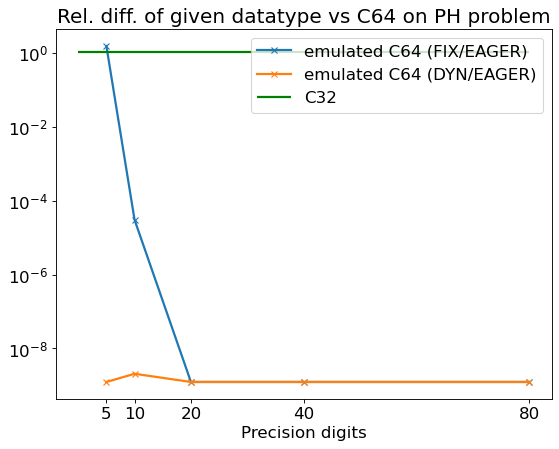

In [5]:
nocc = 10
nvir = 100
phi = 5

precision_digits = [5, 10, 20, 40, 80]
relative_error = [
    1.509354e+00,
    3.013229e-05,
    1.243872e-09,
    1.243872e-09,
    1.243872e-09
]
relative_error = [
    1.509354e+00,
    3.013229e-05,
    1.243872e-09,
    1.243872e-09,
    1.243872e-09
]
relative_error_DYN = [
    1.242685e-09,
    2.070766e-09,
    1.242685e-09,
    1.242685e-09,
    1.242685e-09
]

plt.figure(figsize=(8, 6), dpi=80)
plt.title("Rel. diff. of given datatype vs C64 on PH problem")
plt.plot(precision_digits, relative_error, marker='x', label='emulated C64 (FIX/EAGER)')
plt.plot(precision_digits, relative_error_DYN, marker='x', label='emulated C64 (DYN/EAGER)')
plt.xticks(precision_digits, labels=precision_digits)
plt.hlines(1.037247e+00, 0, 80, label='C32', colors='green')
plt.yscale('log')
plt.xlabel('Precision digits')
plt.legend()
plt.savefig("error_gb200.png")

To generate this plot the cuBLAS emulation strategy need to be set to `EAGER` to force emulation. This plot also displays the behaviour of the dynamic vs fixed mantissa emulation. The dynamic version evaluates at run time the number of required mantissa bits as the dynamic range of input tensors can only be known at runtime. The scripts for getting previous plot can be found [here](https://gitlab.com/lee-maximee/my-ttgt/-/tree/main/examples/idris-hackathlon-2026-dump/ph/emulated/error?ref_type=heads).